In [12]:
import sys
from pathlib import Path

scripts_path = Path("../scripts").resolve()
sys.path.append(str(scripts_path))

import rq5_function_lib as fl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import numpy as np
import polars as pl
import plotly.express as px
import plotly.graph_objects as go

In [2]:
dir(fl)

['Path',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'anomalies_per_station',
 'anomaly_rate',
 'load_stations',
 'pd',
 'pl',
 'prepare_station_map',
 'total_updates']

## RQ5: E10 - Diesel Price comparison and frquency of anomalies (Diesel price = E10 price//Diesel price > E10 price)

In [3]:
# Pfade
anomalies_path = Path(r"C:\Users\Marvin\Dokumente\Bildung\Uni\dsprojekt\tankerkoenig-data\anomalies")
parquet_base = Path(r"C:\Users\Marvin\Dokumente\Bildung\Uni\dsprojekt\tankerkoenig-data\prices_parquet")

# Lade alle verfügbaren Anomalie-Dateien
anomaly_files = sorted(anomalies_path.glob("*_all_anomalies.parquet"))

print(f"Gefundene Anomalie-Dateien: {len(anomaly_files)}")
for f in anomaly_files:
    print(f"  - {f.name}")


Gefundene Anomalie-Dateien: 13
  - 2014_all_anomalies.parquet
  - 2015_all_anomalies.parquet
  - 2016_all_anomalies.parquet
  - 2017_all_anomalies.parquet
  - 2018_all_anomalies.parquet
  - 2019_all_anomalies.parquet
  - 2020_all_anomalies.parquet
  - 2021_all_anomalies.parquet
  - 2022_all_anomalies.parquet
  - 2023_all_anomalies.parquet
  - 2024_all_anomalies.parquet
  - 2025_all_anomalies.parquet
  - 2026_all_anomalies.parquet


In [4]:
# Define the range of years you want to analyze
start_year = 2020
end_year = 2027

# Combine anomalies from how many years you want to see
dfs = []
for year in range(start_year, end_year): 
    year_file = anomalies_path / f"{year}_all_anomalies.parquet"
    if year_file.exists():
        try:
            df = pl.read_parquet(year_file)
            # Convert date to datetime (only date part, ignore time and timezone)
            df = df.with_columns(
                pl.col("date")
                .str.slice(0, 10)  # Only take YYYY-MM-DD
                .str.to_date()
                .alias("date_parsed")
            )
            dfs.append(df)
            print(f"{year} loaded ({df.height:,} anomalies)")
        except Exception as e:
            print(f"X {year} error: {e}")


combined = pl.concat(dfs)
combined = combined.with_columns(
    year=pl.col("date_parsed").dt.year(),
    month=pl.col("date_parsed").dt.month(),
    week=pl.col("date_parsed").dt.week()
)
print(f"\nTotal Anomalies: {combined.height:,} from {start_year}-{end_year-1}")


2020 loaded (69,399 anomalies)
2021 loaded (128,843 anomalies)
2022 loaded (52,323,353 anomalies)
2023 loaded (18,748,424 anomalies)
2024 loaded (4,690,880 anomalies)
2025 loaded (3,133,653 anomalies)
2026 loaded (2,055,590 anomalies)

Total Anomalies: 81,150,142 from 2020-2026


## E10-Diesel Anomalies per Month (for yearss loaded)

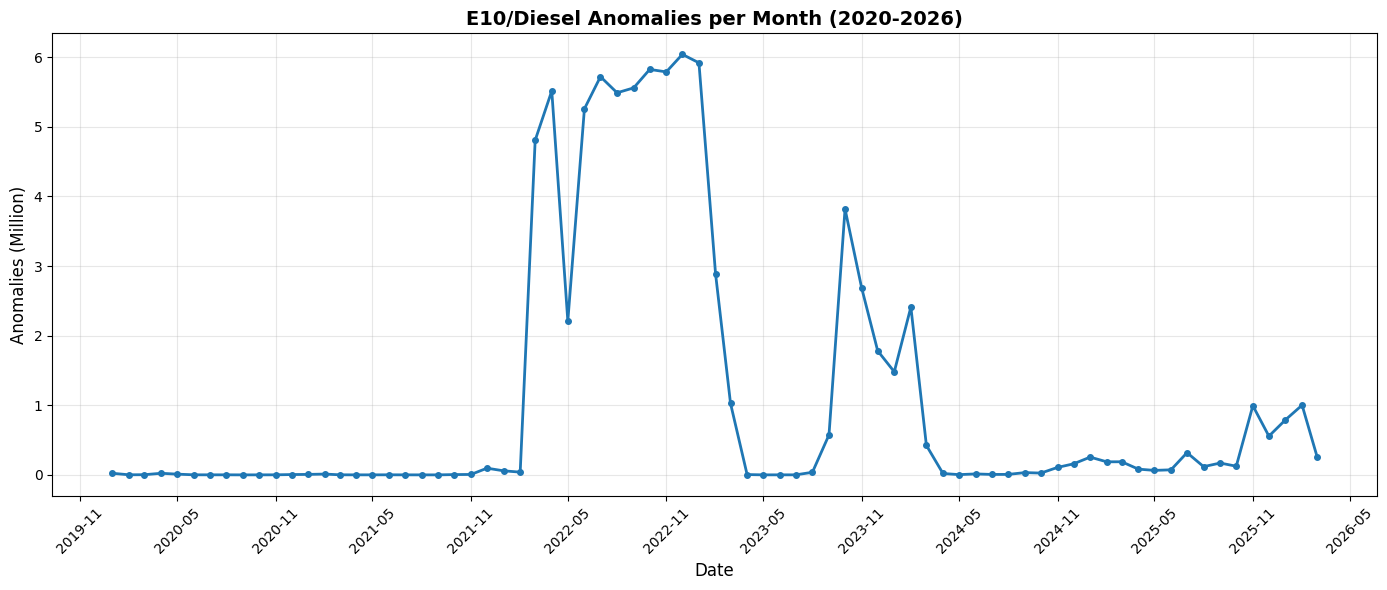

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

anomalies_per_month = combined.group_by(["year", "month"]).agg(pl.len().alias("count")).sort(["year", "month"])
anomalies_df = anomalies_per_month.to_pandas()
anomalies_df["date"] = pd.to_datetime(anomalies_df[["year", "month"]].assign(day=1))

ax.plot(anomalies_df["date"], anomalies_df["count"]/1_000_000, marker="o", linewidth=2, markersize=4)
ax.set_title(f"E10/Diesel Anomalies per Month ({start_year}-{end_year-1})", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Anomalies (Million)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:
import polars as pl

xyz = pl.read_parquet("C:/Users/Marvin/Dokumente/Bildung/Uni/dsprojekt/tankerkoenig-data/anomalies/2015_04_anomalies.parquet")
print(xyz.head(10))
print(xyz.schema)

shape: (10, 6)
┌────────────────────────┬────────────────────────────┬────────┬────────┬──────────────┬───────────┐
│ date                   ┆ station_uuid               ┆ diesel ┆ e10    ┆ dieselchange ┆ e10change │
│ ---                    ┆ ---                        ┆ ---    ┆ ---    ┆ ---          ┆ ---       │
│ str                    ┆ str                        ┆ f64    ┆ f64    ┆ i64          ┆ i64       │
╞════════════════════════╪════════════════════════════╪════════╪════════╪══════════════╪═══════════╡
│ 2015-04-01 07:50:01+02 ┆ 3277b3b6-38e4-4013-83ea-51 ┆ 1.399  ┆ 1.379  ┆ 1            ┆ 1         │
│                        ┆ 90c4…                      ┆        ┆        ┆              ┆           │
│ 2015-04-01 09:02:01+02 ┆ b4346833-4178-4d5f-8981-9e ┆ 1.209  ┆ -0.001 ┆ 1            ┆ 1         │
│                        ┆ a144…                      ┆        ┆        ┆              ┆           │
│ 2015-04-01 10:02:01+02 ┆ 54ee99f1-a804-46de-b881-2d ┆ -0.001 ┆ -0.001 ┆ 1 

## Total Anomalies per year

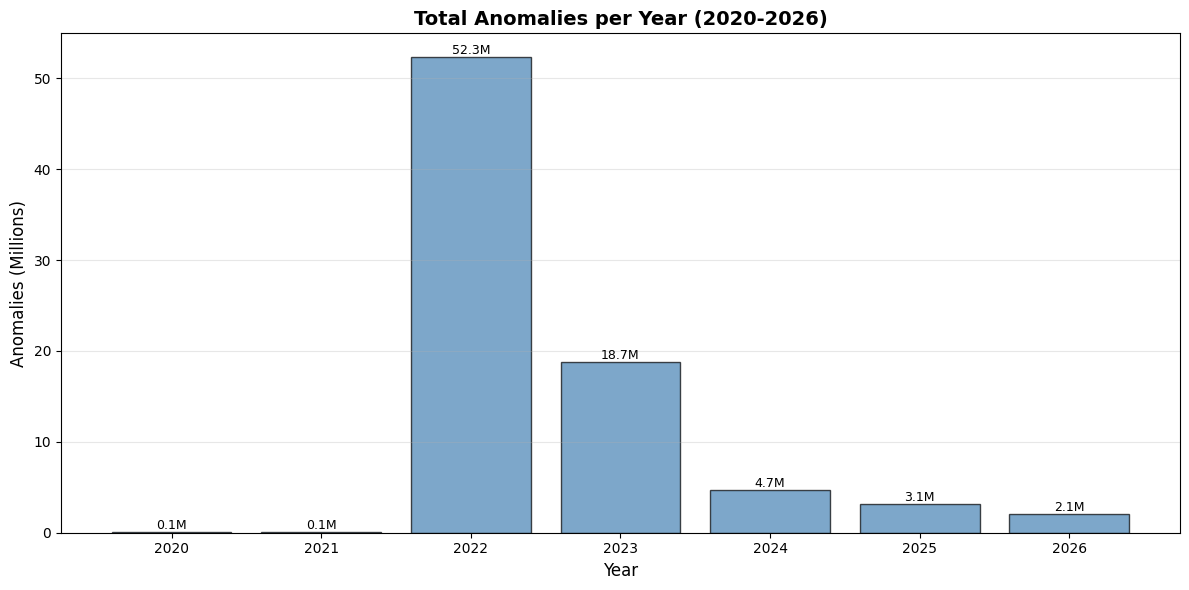

In [7]:
# Anomalies per year
fig, ax = plt.subplots(figsize=(12, 6))

anomalies_per_year = combined.group_by("year").agg(pl.len().alias("count")).sort("year")
year_data = anomalies_per_year.to_pandas()

bars = ax.bar(year_data["year"], year_data["count"]/1_000_000, color="steelblue", alpha=0.7, edgecolor="black")
ax.set_title(f"Total Anomalies per Year ({start_year}-{end_year-1})", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Anomalies (Millions)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.1f}M",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## Distribution of Price anomalies by hour of day for any year

In [43]:
year = 2022
year_file = anomalies_path / f"{year}_all_anomalies.parquet"

df = (
    pl.scan_parquet(year_file)
    .select("date")
    .with_columns(
        pl.col("date")
        .str.replace(r"([+-]\d{2})$", r"$1:00")   # ChatGPT fix timezone format
        .str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%z")
        .dt.hour()
        .alias("hour")
    )
    .group_by("hour")
    .len()
    .sort("hour")
    .collect()
)

fig = px.bar(
    df,
    x="hour",
    y="len",
    title=f"Anomalies by Hour ({year})"
)

fig.update_layout(
    xaxis_title="Hour of Day",
    yaxis_title="Number of Anomalies"
)
fig.show()

In [29]:
import importlib
import rq5_function_lib

importlib.reload(rq5_function_lib)

<module 'rq5_function_lib' from 'C:\\Users\\Marvin\\Dokumente\\Bildung\\Uni\\dsprojekt\\Data-Science-Projekt\\scripts\\rq5_function_lib.py'>

### Top 100 Gas Stations with highest anomalie rate (= anomalies/price updates) between 2020 and 2026

In [32]:
stations_csv = Path(r"C:/Users/Marvin/Dokumente/Bildung/Uni/dsprojekt/tankerkoenig-data/stations/stations.csv")
stations_parquet = Path("stations.parquet")

stations = fl.load_stations(stations_csv, stations_parquet)

# counts
anomalies = fl.anomalies_per_station(combined)

updates = fl.total_updates(parquet_base, start_year, end_year)

station_stats = fl.anomaly_rate(anomalies, updates)

station_stats = station_stats.filter(
    pl.col("updates") > 50000
)
gas_stations = 100
map_df = fl.prepare_station_map(station_stats, stations, top_n=gas_stations)

station_data = map_df.to_pandas()


fig = go.Figure()

station_data = map_df.to_pandas()

fig = px.scatter_map(
    station_data,
    lat="latitude",
    lon="longitude",
    size="anomaly_rate",
    color="anomaly_rate",
    hover_name="name",
    hover_data={
        "anomalies": True,
        "updates": True,
        "anomaly_rate": ":.3f"
    },
    size_max=18,
    zoom=6,
    height=600,
    title=f"Top {gas_stations} Gas Stations by Anomaly Rate ({start_year}-{end_year-1})",
    color_continuous_scale="Turbo"
)

fig.update_layout(
    mapbox_style="open-street-map",
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

display(
    map_df
    .select(["name", "anomalies", "updates", "anomaly_rate"])
    .sort("anomaly_rate", descending=True)
)

name,anomalies,updates,anomaly_rate
str,u32,i64,f64
"""ELAN LEIPZIG""",12531,54240,0.231029
"""TOTAL LEIPZIG""",12296,53671,0.2291
"""TOTAL LEIPZIG""",12941,57400,0.225453
"""TOTAL LEIPZIG""",12997,59231,0.219429
"""TOTAL LEIPZIG""",11477,52990,0.216588
…,…,…,…
"""Unknown """,9274,53398,0.173677
"""TOTAL SONNEBERG""",10169,58686,0.173278
"""LD Tankstelle Westheim Rosenga…",9453,54640,0.173005


In [ ]:
file = Path(r"D:\Tankdaten\anomalies\price_diff_2022.parquet")

df = pl.read_parquet(file)

# Datum sicherstellen
df = df.with_columns(
    pl.col("date").str.strptime(pl.Datetime, strict=False)
)

# nach Datum sortieren
df = df.sort("date")

plt.figure(figsize=(12,6))
plt.scatter(df["date"], df["price_diff"], s=3)

plt.title("Diesel - E10 Price Difference (2022)")
plt.xlabel("Date")
plt.ylabel("Price Difference (€)")
plt.show()

FileNotFoundError: Das System kann die angegebene Datei nicht finden. (os error 2): ...:/Users/Marvin/Dokumente/Bildung/Uni/dsprojekt/tankerkoenig-data/price_diff_2022.parquet (set POLARS_VERBOSE=1 to see full path)